In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def extract_largest_square(img):
    """
    가장 큰 contour의 bounding square만 남기고 나머지는 검정색으로 처리하는 함수.
    img: 2D numpy array (grayscale)
    """
    # 1. Edge 검출 (Canny)
    edges = cv2.Canny(img, 50, 150)

    # 2. Contour 추출
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 3. 가장 넓은 사각형 찾기
    max_area = 0
    best_rect = None
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h
        if area > max_area:
            max_area = area
            best_rect = (x, y, w, h)

    # 4. 새 마스크 생성하여 사각형 내부만 살리기
    mask = np.zeros_like(img)
    if best_rect:
        x, y, w, h = best_rect
        mask[y:y+h, x:x+w] = img[y:y+h, x:x+w]

    return mask

def extract_largest_crop_and_resize(img, output_size=32):
    """
    가장 큰 contour를 포함하는 사각형 영역만 crop한 후, 지정 크기로 resize하여 반환
    img: 2D numpy array (grayscale)
    output_size: 최종 출력 크기 (정사각형, 예: 32)
    """
    # 1. Edge 검출 (Canny)
    edges = cv2.Canny(img, 150, 200)

    # 2. Contour 추출
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 3. 가장 큰 contour의 bounding box 찾기
    max_area = 0
    best_rect = None
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h
        if area > max_area:
            max_area = area
            best_rect = (x, y, w, h)

    if best_rect:
        x, y, w, h = best_rect
        cropped = img[y:y+h, x:x+w]
        resized = cv2.resize(cropped, (output_size, output_size), interpolation=cv2.INTER_AREA)
        return resized
    else:
        # fallback: resize 원본
        return cv2.resize(img, (output_size, output_size), interpolation=cv2.INTER_AREA)


In [19]:
import pandas as pd
answer = pd.read_csv('data/label.txt', delimiter=',')
answer

,ID,label
0,0,airplane
1,1,cat
2,2,emotion_face
3,3,building
4,4,truck
...,...,...
245,245,police_car
246,246,cat
247,247,building
248,248,police_car


TypeError: Image data of dtype object cannot be converted to float

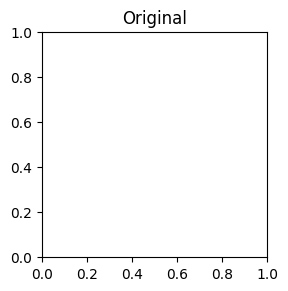

In [ ]:
path  = './data/train/TRAIN_004_2.png'
# ✅ 예시 사용법
img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
processed_img = extract_largest_square(img)

# 결과 시각화
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(img, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Cropped Square")
plt.imshow(processed_img, cmap="gray")
plt.show()
